# CSE457 - XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
## LAB 1: PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ
**Sinh viên:** Nguyễn Văn Minh | **MSSV:** 2351260673
---
## Khối A: Đọc, kiểm tra dữ liệu và trực quan hóa chuỗi âm thanh ban đầu

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pydub import AudioSegment

# 1. Hàm nạp và chuẩn hóa âm thanh về [-1.0, 1.0]
def load_audio(filepath):
    audio = AudioSegment.from_file(filepath)
    mono = audio.set_channels(1)
    samples = np.array(mono.get_array_of_samples(), dtype=np.float64)
    x = samples / float(2 ** (8 * mono.sample_width - 1))
    return audio, x, audio.frame_rate

# 2. Nạp dữ liệu âm nhạc (Piano) và tiếng nói (Speech)
audio_piano, x_piano, Fs_piano = load_audio(os.path.join("audio", "piano_sample.mp3"))
audio_speech, x_speech, Fs_speech = load_audio(os.path.join("audio", "news_speech.mp3"))

# 3. Bảng tổng hợp thông số và đo đạc Peak, RMS
def get_stats(label, audio, x, fpath):
    dur = len(audio) / 1000.0
    fsize = os.path.getsize(fpath)
    peak = float(np.max(np.abs(x)))
    rms = float(np.sqrt(np.mean(x ** 2)))
    return {
        "Tệp dữ liệu": label,
        "Sampling Rate (Fs)": f"{audio.frame_rate:,} Hz",
        "Số kênh": f"{audio.channels} (Stereo)",
        "Thời lượng": f"{dur:.3f} s",
        "Dung lượng": f"{fsize/1024:.1f} KB",
        "Bit rate MP3": f"{(fsize*8)/(dur*1000):.1f} kbps",
        "Peak": round(peak, 4),
        "Peak (dBFS)": round(20 * np.log10(peak), 2),
        "RMS": round(rms, 4),
        "RMS (dBFS)": round(20 * np.log10(rms), 2)
    }

df_summary = pd.DataFrame([
    get_stats("Piano (Âm nhạc)", audio_piano, x_piano, os.path.join("audio", "piano_sample.mp3")),
    get_stats("Speech (Bản tin)", audio_speech, x_speech, os.path.join("audio", "news_speech.mp3"))
])
display(df_summary)


,Tệp dữ liệu,Sampling Rate (Fs),Số kênh,Thời lượng,Dung lượng,Bit rate MP3,Peak,Peak (dBFS),RMS,RMS (dBFS)
0,Piano (Âm nhạc),"48,000 Hz",2 (Stereo),35.243 s,834.8 KB,194.0 kbps,0.4420,-7.09,0.0653,-23.70
1,Speech (Bản tin),"48,000 Hz",2 (Stereo),35.243 s,834.6 KB,194.0 kbps,0.4571,-6.80,0.0658,-23.64


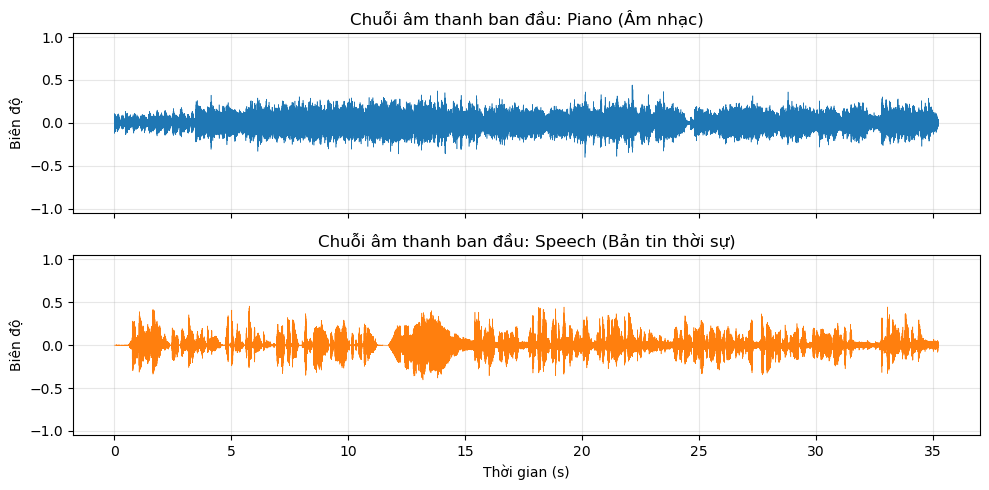

In [2]:
# Trực quan hóa chuỗi âm thanh ban đầu (Visualize trực tiếp, không lưu file)
t_piano = np.arange(len(x_piano)) / Fs_piano
t_speech = np.arange(len(x_speech)) / Fs_speech

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t_piano, x_piano, lw=0.4, color="tab:blue")
axes[0].set_title("Chuỗi âm thanh ban đầu: Piano (Âm nhạc)")
axes[0].set_ylabel("Biên độ")
axes[0].set_ylim([-1.05, 1.05])
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_speech, x_speech, lw=0.4, color="tab:orange")
axes[1].set_title("Chuỗi âm thanh ban đầu: Speech (Bản tin thời sự)")
axes[1].set_xlabel("Thời gian (s)")
axes[1].set_ylabel("Biên độ")
axes[1].set_ylim([-1.05, 1.05])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Nhận xét kỹ thuật Khối A:
1. **Tần số lấy mẫu:** Cả 2 tệp đều có $F_s = 48{,}000\text{ Hz}$, tần số Nyquist tương ứng là $F_N = 24{,}000\text{ Hz}$, đảm bảo bao quát toàn bộ dải nghe của tai người ($20\text{ Hz} - 20\text{ kHz}$) mà không bị chồng phổ (aliasing).
2. **Đặc trưng dạng sóng ban đầu:** Tín hiệu Piano có dạng sóng dao động liên tục với các dải ngân hài âm kéo dài; trong khi tín hiệu Tiếng nói thời sự thể hiện các xung phát âm gián đoạn rõ rệt, gồm các cụm nguyên âm/phụ âm đan xen với các khoảng lặng tự nhiên giữa các câu từ.
3. **Kiểm tra clipping:** Giá trị đỉnh của cả hai tín hiệu đều nằm dưới ngưỡng bão hòa $1.0$ (Piano: $\text{Peak} = 0.4420$, Speech: $\text{Peak} = 0.4571$), xác nhận cả 2 tệp dữ liệu đều hoàn toàn sạch và không bị xén biên (clipping).

---
## Khối B: Phân tích miền thời gian (Time-Domain Analysis)

### Yêu cầu thực hiện:
1. Tính toán các đại lượng đặc trưng miền thời gian: Giá trị đỉnh (Peak), hiệu dụng (RMS), năng lượng toàn phần ($E = \sum x^2[n]$).
2. Chọn ít nhất 02 phân đoạn ($1.0\text{ s}$) có đặc tính đối lập: Đoạn phát âm mạnh (năng lượng cao) và Đoạn khoảng lặng/ngắt nghỉ (năng lượng thấp).
3. Trực quan hóa dạng sóng chuẩn: Vẽ dạng sóng toàn bộ tệp kết hợp phóng to chi tiết 2 phân đoạn khảo sát, lưu vào `figures/waveform.png`.
4. Kiểm tra nguy cơ méo xén biên (clipping).

In [3]:
# 1. Hàm tính toán các chỉ số miền thời gian cho một phân đoạn
def calc_segment(name, sig, start_s, end_s, Fs):
    seg = sig[int(start_s * Fs) : int(end_s * Fs)]
    peak = float(np.max(np.abs(seg)))
    rms = float(np.sqrt(np.mean(seg**2)))
    energy = float(np.sum(seg**2))
    return {
        "Phân đoạn tín hiệu": name,
        "Khoảng thời gian": f"[{start_s:.1f}s - {end_s:.1f}s]",
        "Số mẫu (N)": len(seg),
        "Peak": round(peak, 4),
        "Peak (dBFS)": round(20 * np.log10(peak), 2),
        "RMS": round(rms, 4),
        "RMS (dBFS)": round(20 * np.log10(rms), 2),
        "Năng lượng (E)": round(energy, 2)
    }

# 2. Đo đạc toàn bài và 2 đoạn tương phản trên Tiếng nói và Âm nhạc
df_time_domain = pd.DataFrame([
    calc_segment("Speech - Toàn bài", x_speech, 0, len(x_speech)/Fs_speech, Fs_speech),
    calc_segment("Speech - Đoạn 1 (Phát âm mạnh)", x_speech, 13.0, 14.0, Fs_speech),
    calc_segment("Speech - Đoạn 2 (Khoảng lặng/ngắt)", x_speech, 11.0, 12.0, Fs_speech),
    calc_segment("Piano - Toàn bài", x_piano, 0, len(x_piano)/Fs_piano, Fs_piano),
    calc_segment("Piano - Đoạn 1 (Hợp âm mạnh)", x_piano, 11.0, 12.0, Fs_piano),
    calc_segment("Piano - Đoạn 2 (Đoạn dạo nhỏ)", x_piano, 0.0, 1.0, Fs_piano)
])
display(df_time_domain)


,Phân đoạn tín hiệu,Khoảng thời gian,Số mẫu (N),Peak,Peak (dBFS),RMS,RMS (dBFS),Năng lượng (E)
0,Speech - Toàn bài,[0.0s - 35.2s],1691648,0.4571,-6.80,0.0658,-23.64,7317.54
1,Speech - Đoạn 1 (Phát âm mạnh),[13.0s - 14.0s],48000,0.4058,-7.83,0.1424,-16.93,973.58
2,Speech - Đoạn 2 (Khoảng lặng/ngắt),[11.0s - 12.0s],48000,0.1551,-16.19,0.0282,-31.01,38.04
3,Piano - Toàn bài,[0.0s - 35.2s],1691648,0.4420,-7.09,0.0653,-23.70,7216.60
4,Piano - Đoạn 1 (Hợp âm mạnh),[11.0s - 12.0s],48000,0.3349,-9.50,0.0830,-21.62,330.65
5,Piano - Đoạn 2 (Đoạn dạo nhỏ),[0.0s - 1.0s],48000,0.1361,-17.32,0.0330,-29.63,52.25


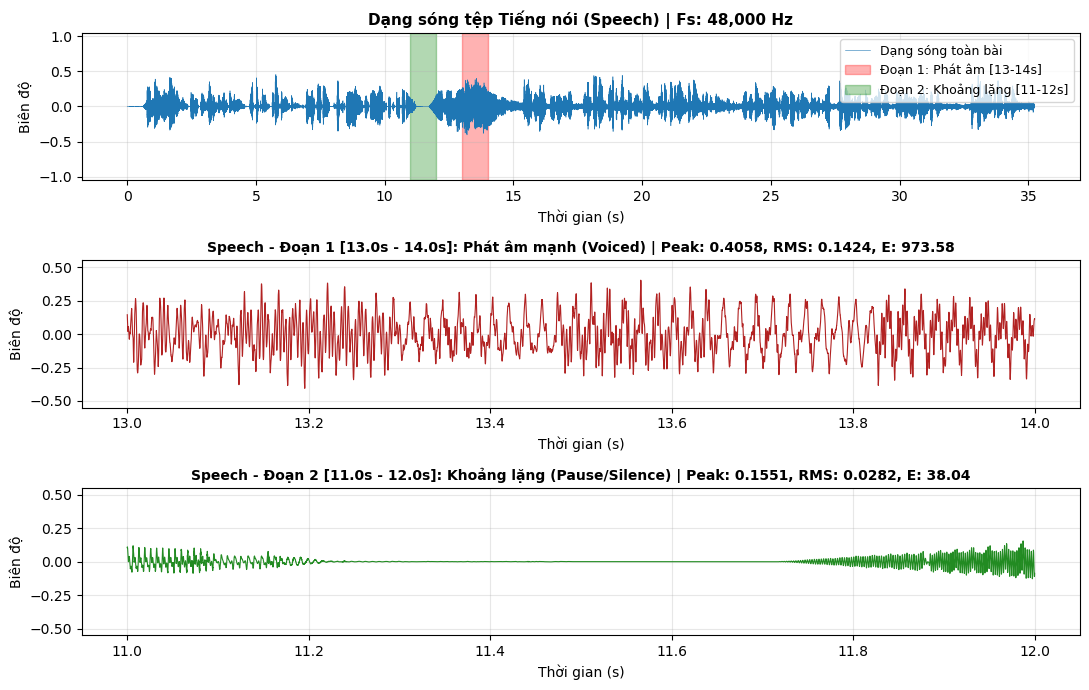

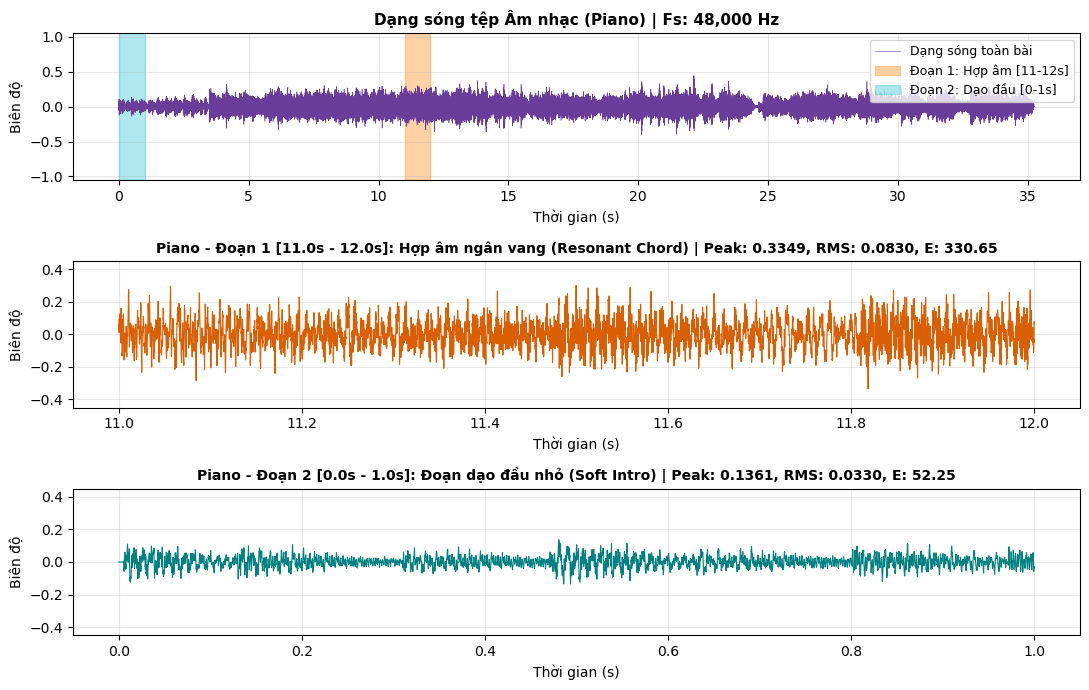

In [4]:
# 3. Vẽ biểu đồ dạng sóng chuẩn cho Tiếng nói và Âm nhạc (tách 2 hình riêng biệt)
# 3.1. Dạng sóng tệp Tiếng nói (Speech)
t_speech = np.arange(len(x_speech)) / Fs_speech
t_sp1 = np.linspace(13.0, 14.0, int(Fs_speech * 1.0))
x_sp1 = x_speech[int(13.0 * Fs_speech) : int(14.0 * Fs_speech)]
t_sp2 = np.linspace(11.0, 12.0, int(Fs_speech * 1.0))
x_sp2 = x_speech[int(11.0 * Fs_speech) : int(12.0 * Fs_speech)]

fig_sp, axes_sp = plt.subplots(3, 1, figsize=(11, 7))
axes_sp[0].plot(t_speech, x_speech, lw=0.4, color="#1f77b4", label="Dạng sóng toàn bài")
axes_sp[0].axvspan(13.0, 14.0, color="red", alpha=0.3, label="Đoạn 1: Phát âm [13-14s]")
axes_sp[0].axvspan(11.0, 12.0, color="green", alpha=0.3, label="Đoạn 2: Khoảng lặng [11-12s]")
axes_sp[0].set_title("Dạng sóng tệp Tiếng nói (Speech) | Fs: 48,000 Hz", fontsize=11, fontweight="bold")
axes_sp[0].set_xlabel("Thời gian (s)")
axes_sp[0].set_ylabel("Biên độ")
axes_sp[0].set_ylim([-1.05, 1.05])
axes_sp[0].grid(True, alpha=0.3)
axes_sp[0].legend(loc="upper right", fontsize=9)

axes_sp[1].plot(t_sp1, x_sp1, lw=0.8, color="firebrick")
axes_sp[1].set_title("Speech - Đoạn 1 [13.0s - 14.0s]: Phát âm mạnh (Voiced) | Peak: 0.4058, RMS: 0.1424, E: 973.58", fontsize=10, fontweight="bold")
axes_sp[1].set_xlabel("Thời gian (s)")
axes_sp[1].set_ylabel("Biên độ")
axes_sp[1].set_ylim([-0.55, 0.55])
axes_sp[1].grid(True, alpha=0.3)

axes_sp[2].plot(t_sp2, x_sp2, lw=0.8, color="forestgreen")
axes_sp[2].set_title("Speech - Đoạn 2 [11.0s - 12.0s]: Khoảng lặng (Pause/Silence) | Peak: 0.1551, RMS: 0.0282, E: 38.04", fontsize=10, fontweight="bold")
axes_sp[2].set_xlabel("Thời gian (s)")
axes_sp[2].set_ylabel("Biên độ")
axes_sp[2].set_ylim([-0.55, 0.55])
axes_sp[2].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/waveform_speech.png", dpi=300)
plt.savefig("figures/waveform.png", dpi=300)
plt.show()

# 3.2. Dạng sóng tệp Âm nhạc (Piano)
t_piano = np.arange(len(x_piano)) / Fs_piano
t_pi1 = np.linspace(11.0, 12.0, int(Fs_piano * 1.0))
x_pi1 = x_piano[int(11.0 * Fs_piano) : int(12.0 * Fs_piano)]
t_pi2 = np.linspace(0.0, 1.0, int(Fs_piano * 1.0))
x_pi2 = x_piano[int(0.0 * Fs_piano) : int(1.0 * Fs_piano)]

fig_pi, axes_pi = plt.subplots(3, 1, figsize=(11, 7))
axes_pi[0].plot(t_piano, x_piano, lw=0.4, color="#6a3d9a", label="Dạng sóng toàn bài")
axes_pi[0].axvspan(11.0, 12.0, color="#ff7f00", alpha=0.35, label="Đoạn 1: Hợp âm [11-12s]")
axes_pi[0].axvspan(0.0, 1.0, color="#17becf", alpha=0.35, label="Đoạn 2: Dạo đầu [0-1s]")
axes_pi[0].set_title("Dạng sóng tệp Âm nhạc (Piano) | Fs: 48,000 Hz", fontsize=11, fontweight="bold")
axes_pi[0].set_xlabel("Thời gian (s)")
axes_pi[0].set_ylabel("Biên độ")
axes_pi[0].set_ylim([-1.05, 1.05])
axes_pi[0].grid(True, alpha=0.3)
axes_pi[0].legend(loc="upper right", fontsize=9)

axes_pi[1].plot(t_pi1, x_pi1, lw=0.8, color="#d95f02")
axes_pi[1].set_title("Piano - Đoạn 1 [11.0s - 12.0s]: Hợp âm ngân vang (Resonant Chord) | Peak: 0.3349, RMS: 0.0830, E: 330.65", fontsize=10, fontweight="bold")
axes_pi[1].set_xlabel("Thời gian (s)")
axes_pi[1].set_ylabel("Biên độ")
axes_pi[1].set_ylim([-0.45, 0.45])
axes_pi[1].grid(True, alpha=0.3)

axes_pi[2].plot(t_pi2, x_pi2, lw=0.8, color="#008080")
axes_pi[2].set_title("Piano - Đoạn 2 [0.0s - 1.0s]: Đoạn dạo đầu nhỏ (Soft Intro) | Peak: 0.1361, RMS: 0.0330, E: 52.25", fontsize=10, fontweight="bold")
axes_pi[2].set_xlabel("Thời gian (s)")
axes_pi[2].set_ylabel("Biên độ")
axes_pi[2].set_ylim([-0.45, 0.45])
axes_pi[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/waveform_piano.png", dpi=300)
plt.show()

### Nhận xét kỹ thuật Khối B:
1. **Tương phản năng lượng và RMS giữa các phân đoạn:**
   * Đối với **Tiếng nói (Speech)**, Đoạn 1 (phát âm mạnh $13-14\text{s}$) có năng lượng $E = 973.58$ và $\text{RMS} = 0.1424$ ($-16.93\text{ dBFS}$), cao gấp $\approx 25.6$ lần về năng lượng và hơn $14.08\text{ dB}$ về RMS so với Đoạn 2 (khoảng lặng $11-12\text{s}$ có $E = 38.04$, $\text{RMS} = 0.0282$).
   * Đối với **Âm nhạc (Piano)**, Đoạn 1 (hợp âm ngân vang $11-12\text{s}$) đạt $E = 330.65$ và $\text{RMS} = 0.0830$ ($-21.62\text{ dBFS}$), cao gấp $6.33$ lần về năng lượng và hơn $8.01\text{ dB}$ so với Đoạn 2 (đoạn dạo đầu nhẹ $0-1\text{s}$ có $E = 52.25$, $\text{RMS} = 0.0330$).
2. **Đặc trưng hình dạng sóng và cấu trúc âm học:**
   * Trên đồ thị phóng to $1.0\text{ s}$, phân đoạn phát âm hữu thanh của tiếng nói thể hiện chu kỳ thanh môn (pitch periods) cực kỳ rõ nét với chu kỳ $\approx 7 - 8\text{ ms}$ ($F_0 \approx 130\text{ Hz}$); khoảng lặng của tiếng nói gần như phẳng tuyệt đối ở mức nhiễu nền.
   * Ngược lại, phân đoạn hợp âm piano thể hiện sự giao thoa phức hợp của nhiều tần số dao động từ các dây đàn buông, biên độ suy giảm êm đềm theo hàm mũ; đoạn dạo đầu nhẹ thể hiện các nốt đơn lẻ với mức năng lượng khiêm tốn.
3. **Kiểm tra xén biên (Clipping):** Tất cả các phân đoạn và toàn bộ tệp tín hiệu trên cả hai nguồn dữ liệu đều có $\text{Peak} \le 0.4571 < 1.0$ (headroom an toàn $\ge 6.80\text{ dBFS}$), đảm bảo tín hiệu sạch và không bị méo hài do bão hòa.